In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [4]:
df = pd.read_csv('../data/images_metadata.csv')

# Wheat

In [3]:
wheat = df.loc[df.crop == 'wheat'].copy()
wheat.head()

,crop,collection_date,genotype,individual,image_path
0,wheat,1,10,1,../data/wheat/images\1_10_1.jpg
1,wheat,1,10,10,../data/wheat/images\1_10_10.jpg
2,wheat,1,10,2,../data/wheat/images\1_10_2.jpg
3,wheat,1,10,3,../data/wheat/images\1_10_3.jpg
4,wheat,1,10,4,../data/wheat/images\1_10_4.jpg


In [ ]:
wn_genos =len(wheat['genotype'].unique())
wn_dates = len(wheat['collection_date'].unique())
wn_individuals = len(wheat['individual'].unique())
wn_images = wheat.shape[0]

print("===============> Wheat <==================")
print(f"Genotypes: ---------> {wn_genos}")
print(f"Dates : ------------> {wn_dates}")
print(f"Images x genotype :-> {wn_individuals}")
print(f"Total of indiviudals screened : {wn_genos* wn_individuals}")
print(f"Total images: ------> {wn_images}")
print(f"Teorical Vs Actual:-> {wn_images} / {wn_individuals * wn_genos *wn_dates} -> {wn_images/ 2000}")
print(f'% Missing data: ----> {round(1-wn_images/ 2000 ,2) * 100} %')

===============> Wheat <==================
Genotypes: ---------> 40
Dates : ------------> 5
Images x genotype :-> 10
Total of indiviudals screened : 400
Total images: ------> 1981
Teorical Vs Actual:-> 1981 / 2000 -> 0.9905
% Missing data: ----> 1.0 %


## Contingency Table Date x Genotype

In [39]:
pd.crosstab(wheat.loc[wheat.genotype.isin(np.arange(1,21)),'collection_date'],
            wheat.loc[wheat.genotype.isin(np.arange(1,21)),'genotype'])

genotype,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
collection_date,,,,,,,,,,,,,,,,,,,,
1,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10
2,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10
3,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,9,10
4,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,9,10
5,10,10,10,10,10,10,10,9,8,10,9,9,10,10,10,10,10,9,9,10


In [38]:
pd.crosstab(wheat.loc[wheat.genotype.isin(np.arange(21,41)),'collection_date'],
            wheat.loc[wheat.genotype.isin(np.arange(21,41)),'genotype'])


genotype,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40
collection_date,,,,,,,,,,,,,,,,,,,,
1,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10
2,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10
3,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10
4,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10
5,9,9,9,10,10,9,10,10,10,10,7,10,10,10,10,9,8,10,10,10


In [143]:
px.imshow(pd.crosstab(wheat.collection_date,
            wheat.genotype).values,
            labels = dict(x = 'Genotype', y = 'Dates', color= 'n_images'),
            x=np.arange(1,41,1),
            y= np.arange(1,6,1),
            title ="Genotypes Vs Dates",
            text_auto=True)

Contingency table shows mainly that date 5 is the most afected and genotypes :

- 31 in date 5 only have 7 images(individuals) out of 10.
- 19 and 37 are have 8/10 images(individuals).
  
In the genotype 19 would be intresting to see if the missing images are from the same indiviudal or not.

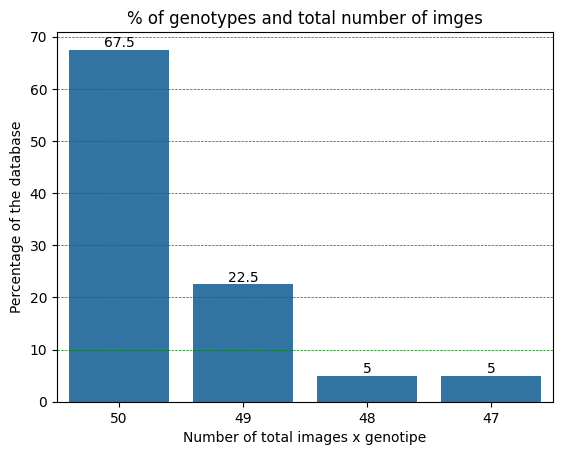

In [40]:
plt.figure()
ax =sns.countplot(wheat.groupby('genotype').agg(n_dates = ('collection_date','count')).reset_index(),
              x ='n_dates', order = [50, 49, 48, 47], stat= 'percent')
plt.title('% of genotypes and total number of imges')
plt.grid(color ='green',linestyle = '--', linewidth = 0.5, axis= "y")
ax.bar_label(ax.containers[0], label_type='edge')
#plt.yticks([0,3,6,9,12,15,18,21,24,27,30,])
plt.xlabel('Number of total images x genotipe')
plt.ylabel('Percentage of the database')
plt.show()

Figure 1: 50 images would be the max number of images per genotype = 5 (number of dates) * 10 (number of indv x genotype)

    - 67.5% of the genotypes contains all the images
    - 22.5% Miss only one image.
    - 10% Miss between 2-3 images.

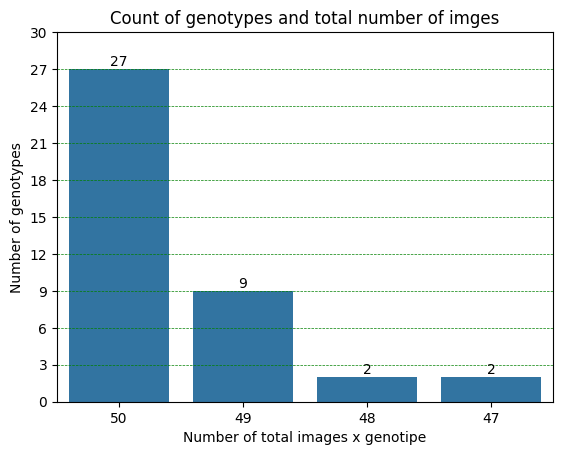

In [41]:
plt.figure()
ax =sns.countplot(wheat.groupby('genotype').agg(n_dates = ('collection_date','count')).reset_index(),
              x ='n_dates', order = [50, 49, 48, 47])
plt.title('Count of genotypes and total number of imges')
plt.grid(color ='green',linestyle = '--', linewidth = 0.5, axis= "y")
plt.yticks([0,3,6,9,12,15,18,21,24,27,30,])
ax.bar_label(ax.containers[0], label_type='edge')
plt.xlabel('Number of total images x genotipe')
plt.ylabel('Number of genotypes')
plt.show()

## Contingency Table individual x genotype

In [42]:
pd.crosstab(wheat.loc[wheat.genotype.isin(np.arange(1,21)),'individual'],
            wheat.loc[wheat.genotype.isin(np.arange(1,21)),'genotype'])

genotype,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
individual,,,,,,,,,,,,,,,,,,,,
1,5,5,5,5,5,5,5,4,4,5,5,5,5,5,5,5,5,5,5,5
2,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5
3,5,5,5,5,5,5,5,5,5,5,5,4,5,5,5,5,5,5,5,5
4,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5
5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5
6,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5
7,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,4,5,5
8,5,5,5,5,5,5,5,5,4,5,4,5,5,5,5,5,5,5,5,5
9,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5


In [43]:
pd.crosstab(wheat.loc[wheat.genotype.isin(np.arange(21,41)),'individual'],
            wheat.loc[wheat.genotype.isin(np.arange(21,41)),'genotype'])


genotype,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40
individual,,,,,,,,,,,,,,,,,,,,
1,5,4,5,5,5,5,5,5,5,5,5,5,5,5,5,5,4,5,5,5
2,5,5,5,5,5,4,5,5,5,5,5,5,5,5,5,4,5,5,5,5
3,4,5,5,5,5,5,5,5,5,5,4,5,5,5,5,5,4,5,5,5
4,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5
5,5,5,5,5,5,5,5,5,5,5,4,5,5,5,5,5,5,5,5,5
6,5,5,5,5,5,5,5,5,5,5,4,5,5,5,5,5,5,5,5,5
7,5,5,4,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5
8,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5
9,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5


In [145]:
px.imshow(pd.crosstab(wheat.individual,
            wheat.genotype).values,
            labels = dict(x = 'Genotype', y = 'Individual', color= 'n_images'),
            x=np.arange(1,41,1),
            y = np.arange(1,11,1),
            title = 'Genotypes vs Individual',
            text_auto=True)

in the contingency table from the genotype and indivudal most of the individuals x genotypes have 5 images (5 dates). There are some with 4 images (dates that mostly are from date 5).
Only genotype 19 has one indivudual that has 2 images instead of 5.

In [44]:
wheat.groupby('individual').agg(n_individuals = ('collection_date','count')).reset_index()

,individual,n_individuals
0,1,196
1,2,198
2,3,196
3,4,200
4,5,199
5,6,199
6,7,198
7,8,198
8,9,200
9,10,197


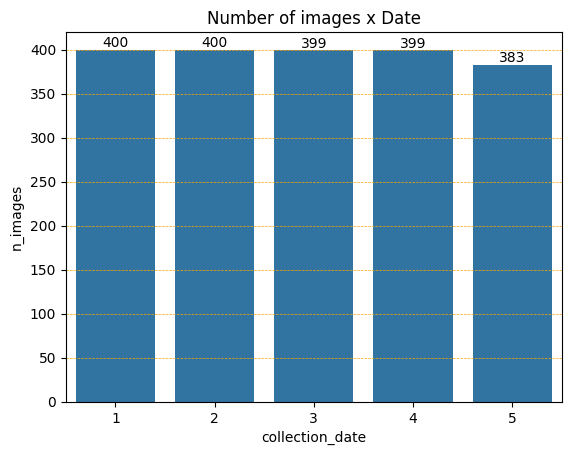

In [46]:
plt.figure()
ax =sns.barplot(wheat.groupby('collection_date').agg(n_images = ('genotype','count')).reset_index(),
            x ='collection_date', y = 'n_images')
plt.title('Number of images x Date')
ax.bar_label(ax.containers[0], label_type='edge')
plt.grid(color ='orange',linestyle = '--', linewidth = 0.5, axis= "y")
#plt.yticks([370,380,390,400])
plt.show()

Figure 2: Number of images per date. The most affected date is the last one, date number 5. The rest of the dates miss one image

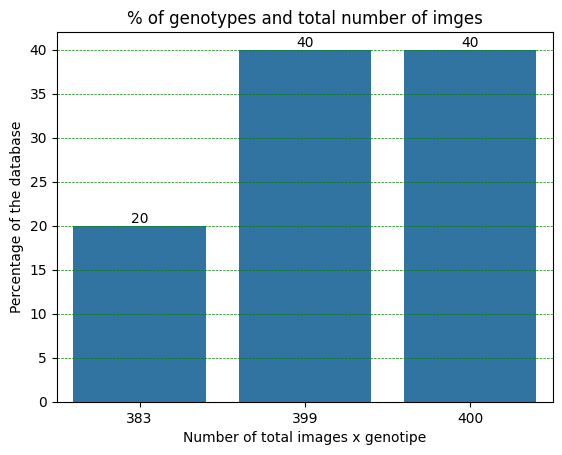

In [51]:
plt.figure()
ax =sns.countplot(wheat.groupby('collection_date').agg(n_dates = ('genotype','count')).reset_index(),
              x ='n_dates', stat= 'percent')
plt.title('% of genotypes and total number of imges')
plt.grid(color ='green',linestyle = '--', linewidth = 0.5, axis= "y")
ax.bar_label(ax.containers[0], label_type='edge')
#plt.yticks([0,3,6,9,12,15,18,21,24,27,30,])
plt.xlabel('Number of total images x genotipe')
plt.ylabel('Percentage of the database')
plt.show()

    - 80% of the dates present all the images or 1 missing image.
    - 20% of the dates (date number: 5 ) present more than 1 missing image (17 missing images).

# Sorghum

In [65]:
sorghum = df.loc[df.crop == 'sorghum'].copy()
sorghum.head()

,crop,collection_date,genotype,individual,image_path
1981,sorghum,1,10,1,../data/sorghum/images\1_10_1.jpg
1982,sorghum,1,10,10,../data/sorghum/images\1_10_10.jpg
1983,sorghum,1,10,2,../data/sorghum/images\1_10_2.jpg
1984,sorghum,1,10,3,../data/sorghum/images\1_10_3.jpg
1985,sorghum,1,10,4,../data/sorghum/images\1_10_4.jpg


In [125]:
sn_genos =len(sorghum['genotype'].unique())
sn_dates = len(sorghum['collection_date'].unique())
sn_individuals = len(sorghum['individual'].unique())
sn_images = sorghum.shape[0]

print("===============> Sorghum <==================")
print(f"Genotypes: ---------> {sn_genos}")
print(f"Dates : ------------> {sn_dates}")
print(f"Images x genotype :-> {sn_individuals}")
print(f"Total of indiviudals screened : {sn_genos* sn_individuals}")
print(f"Total images: ------> {sn_images}")
print(f"Teorical Vs Actual:-> {sn_images} / {sn_individuals * sn_genos *sn_dates} -> {sn_images/ 4000}")
print(f'% Missing data: ----> {round(1-sn_images/ 4000 ,2) * 100} %')

===============> Sorghum <==================
Genotypes: ---------> 80
Dates : ------------> 5
Images x genotype :-> 10
Total of indiviudals screened : 800
Total images: ------> 3825
Teorical Vs Actual:-> 3825 / 4000 -> 0.95625
% Missing data: ----> 4.0 %


## Sorghum heatmap Genotype vs Dates.

In [103]:
px.imshow(pd.crosstab(sorghum.loc[sorghum['genotype'].isin(np.arange(1,41,1))].collection_date,
            sorghum.loc[sorghum['genotype'].isin(np.arange(1,41,1))].genotype).values,
            labels = dict(x = 'Genotype', y = 'Dates', color= 'n_images'),
            x=np.arange(1,41,1),
            y= np.arange(1,6,1),
            title = 'Genotype Vs Dates (1 - 40)',
            text_auto=True)

In [104]:
px.imshow(pd.crosstab(sorghum.loc[sorghum['genotype'].isin(np.arange(41,81,1))].collection_date,
            sorghum.loc[sorghum['genotype'].isin(np.arange(41,81,1))].genotype).values,
            labels = dict(x = 'Genotype', y = 'Dates', color= 'n_images'),
            x=np.arange(41,81,1),
            y= np.arange(1,6,1),
            title = 'Genotype Vs Dates (41 - 80)',
            text_auto=True)

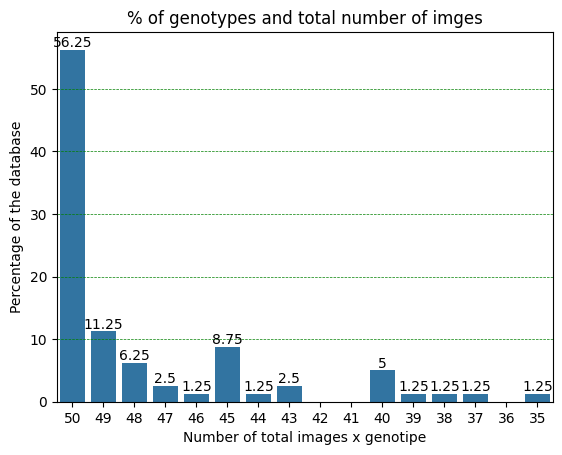

In [ ]:
plt.figure()
ax =sns.countplot(sorghum.groupby('genotype').agg(n_dates = ('collection_date','count')).reset_index(),
              x ='n_dates', order = np.arange(35,51,1)[::-1] ,stat= 'percent')
plt.title('% of genotypes and total number of imges')
plt.grid(color ='green',linestyle = '--', linewidth = 0.5, axis= "y")
ax.bar_label(ax.containers[0], label_type='edge')
plt.xlabel('Number of total images x genotipe')
plt.ylabel('Percentage of the database')
plt.show()

 - 67.5% of the Genotypes all or miss only one image.
 - 22.5%  of the Genotypes miss between 1-7 images.
 - 10 % of the Genotypes miss more than 7 images 

## Sorghum Genotype vs indivudals.

In [117]:
px.imshow(pd.crosstab(sorghum.loc[sorghum['genotype'].isin(np.arange(1,41,1))].individual,
            sorghum.loc[sorghum['genotype'].isin(np.arange(1,41,1))].genotype).values,
            labels = dict(x = 'Genotype', y = 'Individual', color= 'n_images'),
            x=np.arange(1,41,1),
            y= np.arange(1,11,1),
            title = 'Genotype Vs Individual (1 - 40)',
            text_auto=True)

In [120]:
px.imshow(pd.crosstab(sorghum.loc[sorghum['genotype'].isin(np.arange(41,81,1))].individual,
            sorghum.loc[sorghum['genotype'].isin(np.arange(41,81,1))].genotype).values,
            labels = dict(x = 'Genotype', y = 'Individual', color= 'n_images'),
            x=np.arange(41,81,1),
            y= np.arange(1,11,1),
            title = 'Genotype Vs Individual (41 - 80)',
            text_auto=True)

 - Genotypes 8,14,25,37,55,63,70,79 have missing all images from the first date.

 - Genotypes 10,15, 22, 34, 46,51, 58,70 have missing half of data from the second date. 

  The most afected genotype is 70 where it have missing the first date and half of the second date.

  There are some individuals with only 1,2 or 3 images only.


Text(0.5, 1.0, 'Number of indiviudals vs dates and images x date.')

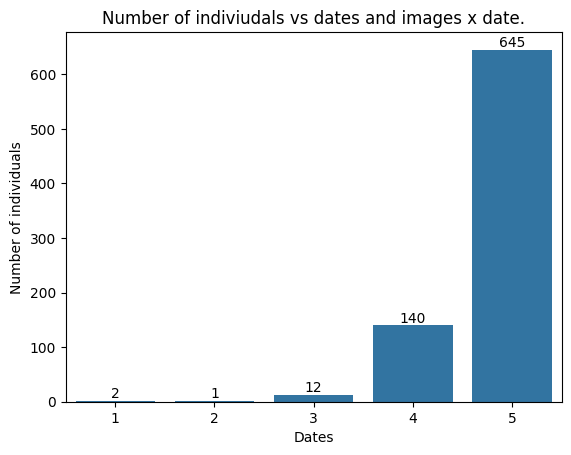

In [141]:
plt.figure()
ax =sns.countplot(sorghum.groupby(['genotype', 'individual']).agg(gen_ind = ('collection_date','count')).reset_index(),
                  x ='gen_ind')
ax.bar_label(ax.containers[0], label_type='edge')
plt.ylabel('Number of individuals')
plt.xlabel('Dates')
plt.title('Number of indiviudals vs dates and images x date.')

Text(0.5, 1.0, '% indiviudals vs dates and images x date.')

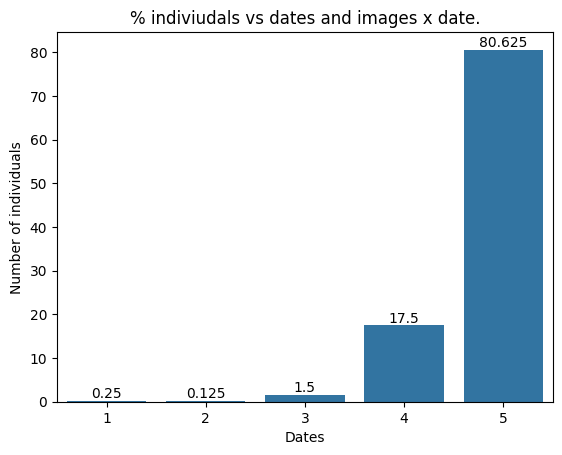

In [142]:
plt.figure()
ax =sns.countplot(sorghum.groupby(['genotype', 'individual']).agg(gen_ind = ('collection_date','count')).reset_index(),
                  x ='gen_ind', stat='percent')
ax.bar_label(ax.containers[0], label_type='edge')
plt.ylabel('Number of individuals')
plt.xlabel('Dates')
plt.title('% indiviudals vs dates and images x date.')

80% of the individuals contains are complete.

18% of the individuals only miss one date.

1.5% of the individuals miss 2 dates.

0.3% of the individuals miss 3 or more dates.

# Resume

*Wheat* data contain less images. 2000 vs 4000 from sorghum. The same for the genotypes and individuals phenotyped been the half of the sorghum experiment.

*Wheat* data only present 1% of missing values. which apparently doesnt represent a problem. Althogh they are concentrated mainly on the 5th date. These missing values are distributed between genotypes.

*Sorghum* contains 4 % of missing values in very specific combination of date x genotype.
First and second date are the most afected. being the genotypes 8,14,25,37,55,63,70,79 afected by the first date with 0 images and 10,15, 22, 34, 46,51, 58,70 genotypes afected by the second date only the half of the individuals contains iamges.
This problem might due to more variability on the sorghum specificaly floral sincronization which is difficoult to acomplish in Sorghum.

As well panicles phenotype might vary from compacted to less compacted ones. Which, it would be intresting to diferenciate between genotypes that contains compacted panciles vs not compacted panicles. That can be a source of imbalance in the dataset.

# Corn

In [5]:
corn = df.loc[df.crop == 'corn'].copy()
corn.head()

,crop,collection_date,genotype,individual,image_path
5806,corn,1,100,1,../data/corn/images\1_100_1.jpg
5807,corn,1,100,2,../data/corn/images\1_100_2.jpg
5808,corn,1,100,3,../data/corn/images\1_100_3.jpg
5809,corn,1,100,4,../data/corn/images\1_100_4.jpg
5810,corn,1,101,1,../data/corn/images\1_101_1.jpg


In [8]:
wn_genos =len(corn['genotype'].unique())
wn_dates = len(corn['collection_date'].unique())
wn_individuals = len(corn['individual'].unique())
wn_images = corn.shape[0]

print("===============> Corn <==================")
print(f"Genotypes: ---------> {wn_genos}")
print(f"Dates : ------------> {wn_dates}")
print(f"Images x genotype :-> {wn_individuals}")
print(f"Total of indiviudals screened : {wn_genos* wn_individuals}")
print(f"Total images: ------> {wn_images}")
print(f"Teorical Vs Actual:-> {wn_images} / {wn_individuals * wn_genos *wn_dates} -> {wn_images/ (wn_individuals * wn_genos *wn_dates)}")
print(f'% Missing data: ----> {round(1-wn_images/ (wn_individuals * wn_genos *wn_dates) ,2) * 100} %')

===============> Corn <==================
Genotypes: ---------> 160
Dates : ------------> 6
Images x genotype :-> 4
Total of indiviudals screened : 640
Total images: ------> 3717
Teorical Vs Actual:-> 3717 / 3840 -> 0.96796875
% Missing data: ----> 3.0 %


In [15]:
px.imshow(pd.crosstab(corn.collection_date,
            corn.genotype).values,
            labels = dict(x = 'Genotype', y = 'Dates', color= 'n_images'),
            x=np.arange(1,161,1),
            y= np.arange(1,7,1),
            title ="Genotypes Vs Dates",
            text_auto=True)

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'coloraxis': 'coloraxis',
              'hovertemplate': 'Genotype: %{x}<br>Dates: %{y}<br>n_images: %{z}<extra></extra>',
              'name': '0',
              'texttemplate': '%{z}',
              'type': 'heatmap',
              'x': {'bdata': ('AQACAAMABAAFAAYABwAIAAkACgALAA' ... 'YAlwCYAJkAmgCbAJwAnQCeAJ8AoAA='),
                    'dtype': 'i2'},
              'xaxis': 'x',
              'y': {'bdata': 'AQIDBAUG', 'dtype': 'i1'},
              'yaxis': 'y',
              'z': {'bdata': ('BAMCAgICAgIEBAQEBAICAgICAgICAg' ... 'QEBAQEBAQEBAQEBAQEBAQEBAQEBAQE'),
                    'dtype': 'i1',
                    'shape': '6, 160'}}],
    'layout': {'coloraxis': {'colorbar': {'title': {'text': 'n_images'}},
                             'colorscale': [[0.0, '#0d0887'], [0.1111111111111111,
                                            '#46039f'], [0.2222222222222222,
                                            '#7201a8'], [0.3333333333333333,
                                            '#9c179e'], [0.4444444444444444,
                                            '#bd3786'], [0.5555555555555556,
                                            '#d8576b'], [0.6666666666666666,
                                            '#ed7953'], [0.7777777777777778,
                                            '#fb9f3a'], [0.8888888888888888,
                                            '#fdca26'], [1.0, '#f0f921']]},
               'template': '...',
               'title': {'text': 'Genotypes Vs Dates'},
               'xaxis': {'anchor': 'y',
                         'constrain': 'domain',
                         'domain': [0.0, 1.0],
                         'scaleanchor': 'y',
                         'title': {'text': 'Genotype'}},
               'yaxis': {'anchor': 'x',
                         'autorange': 'reversed',
                         'constrain': 'domain',
                         'domain': [0.0, 1.0],
                         'title': {'text': 'Dates'}}}
})